### Affine Transform

In this notebook we are going to illustrate the working principle of affine transformations.

In [5]:
import cv2
import math
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

In [6]:
img = cv2.imread('../data/image2_res.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
rows, cols, _ = img.shape

### Zoom via Manual Remapping

Let's start with zoom (scaling). Before reaching for OpenCV's built-in `warpAffine`, we'll first build the zoom "by hand" using `cv2.remap`, which is the lower-level primitive several of OpenCV's geometric-transform functions are built on top of. This will let us see explicitly what a geometric transform actually does to the pixel grid, before we start treating it as a one-line function call.

In [7]:
zoom = 1.75
map_x = np.zeros((rows, cols), dtype=np.float32)
map_y = np.zeros((rows, cols), dtype=np.float32)

# We build the maps with an explicit loop (rather than a vectorized np.meshgrid) so every
# pixel's source coordinate is visible step by step. It's slower than it needs to be — that's
# the point: it's exactly the kind of per-pixel remapping cv2.warpAffine below does for you,
# fast, in a single call.
for r in range(rows):
    for c in range(cols):
        map_x[r, c] = c*1/zoom
        map_y[r, c] = r*1/zoom

There's an important peculiarity in how `cv2.remap` (and, under the hood, every OpenCV warping function) works: `map_x` and `map_y` do **not** say where each *input* pixel moves to. They say the opposite — for every *output* pixel `(r, c)` on the regular integer grid, `map_x[r, c]` and `map_y[r, c]` give the **input** coordinate that should be sampled to fill it. This is called **inverse (backward) mapping**, and it's deliberate: if we instead pushed each input pixel forward to its new location (**forward mapping**), some output pixels could end up with several candidate values and others with none at all (holes), depending on the transform. Backward mapping sidesteps that entirely — every output pixel is guaranteed to get a value, because we always know exactly where to look it up.

That's also why we divide by `zoom` above rather than multiply by it: to fill output pixel `(r, c)` we look up input position `(c / zoom, r / zoom)`, i.e. we read from a *shrunk* region of the input and stretch it across the full output canvas — which is what a magnifying zoom-in actually is.

The computed input coordinates are, in general, no longer integer and, as such, they cannot be directly read from the source image (which only has full pixels). Therefore, the image needs to be **resampled**: `cv2.remap` interpolates between the surrounding source pixels (here using `cv2.INTER_LINEAR`) to estimate the value at that fractional position.

In [8]:
print('Map x')
print(map_x[500:505, 500:505])
print('')
print('Map y')
print(map_y[500:505, 500:505])

Map x
[[285.7143  286.2857  286.85715 287.42856 288.     ]
 [285.7143  286.2857  286.85715 287.42856 288.     ]
 [285.7143  286.2857  286.85715 287.42856 288.     ]
 [285.7143  286.2857  286.85715 287.42856 288.     ]
 [285.7143  286.2857  286.85715 287.42856 288.     ]]

Map y
[[285.7143  285.7143  285.7143  285.7143  285.7143 ]
 [286.2857  286.2857  286.2857  286.2857  286.2857 ]
 [286.85715 286.85715 286.85715 286.85715 286.85715]
 [287.42856 287.42856 287.42856 287.42856 287.42856]
 [288.      288.      288.      288.      288.     ]]


In [9]:
dst = cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR)

(<Axes: >, <matplotlib.image.AxesImage at 0x793023976f30>)

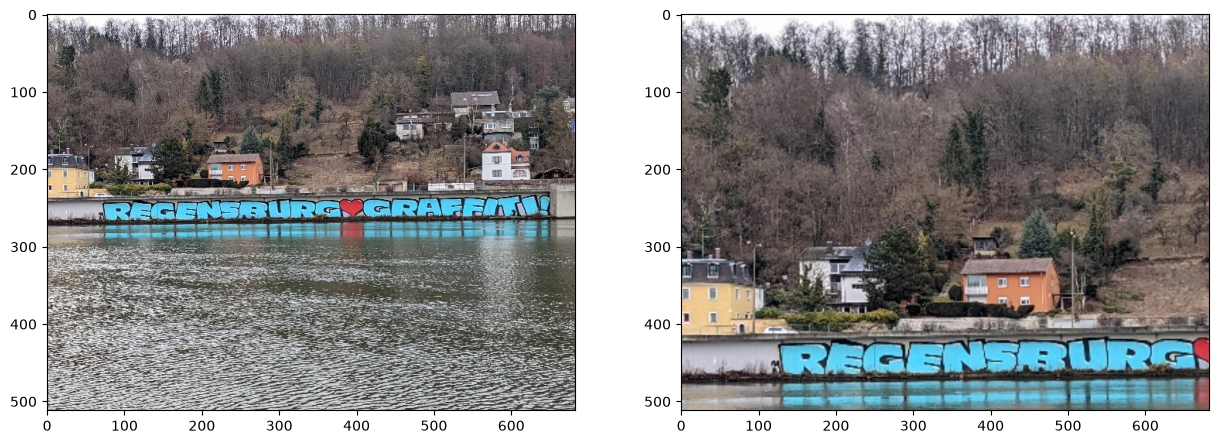

In [10]:
plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(dst)

### Homogeneous Coordinates

So far we mapped each pixel by hand. There is a much more compact way to describe this (and any other affine or projective transform): **homogeneous coordinates**. A Cartesian point $(x, y)$ is represented as $(x, y, 1)$ in projective space — the extra coordinate lets translation, rotation, scaling and shear all be expressed as a **single matrix multiplication**, and lets multiple transforms be **concatenated** into one matrix by multiplying their matrices together, instead of composing separate remaps. Given the transform matrix, OpenCV offers a direct way to apply it to a whole image with `cv2.warpAffine`.

(<Axes: >, <matplotlib.image.AxesImage at 0x79302381b7a0>)

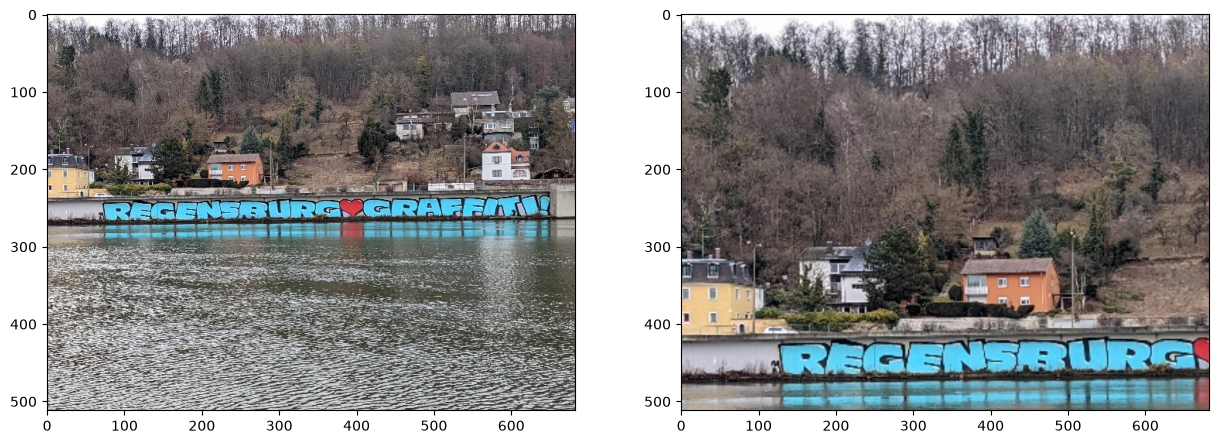

In [11]:
Z = np.array([[zoom, 0, 0], [0, zoom, 0]])
out = cv2.warpAffine(img, Z, (cols, rows))

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(out)

In [12]:
# Let's verify the homogeneous-coordinate claim on a single pixel.
# Take an arbitrary source pixel and express it in homogeneous coordinates (append a 1).
x, y = 100, 50
p_h = np.array([x, y, 1])

# Applying the affine transform is now just a matrix multiplication...
p_zoomed = Z @ p_h
print('Homogeneous matrix multiplication:', p_zoomed)

# ...which matches the plain scaling formula (zoom * x, zoom * y) we used to build map_x/map_y above.
print('Expected (zoom * x, zoom * y)     :', (zoom * x, zoom * y))

Homogeneous matrix multiplication: [175.   87.5]
Expected (zoom * x, zoom * y)     : (175.0, 87.5)


(<Axes: >, <matplotlib.image.AxesImage at 0x793023735e50>)

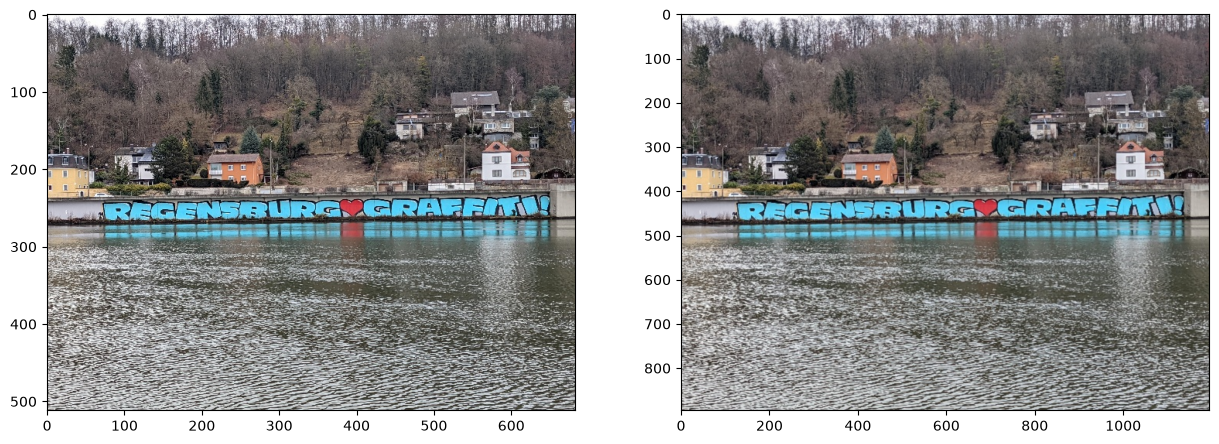

In [13]:
out = cv2.warpAffine(img, Z, (int(zoom*cols), int(zoom*rows)))

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(out)

Image rotation is also an affine transform.

(<Axes: >, <matplotlib.image.AxesImage at 0x79302260ce60>)

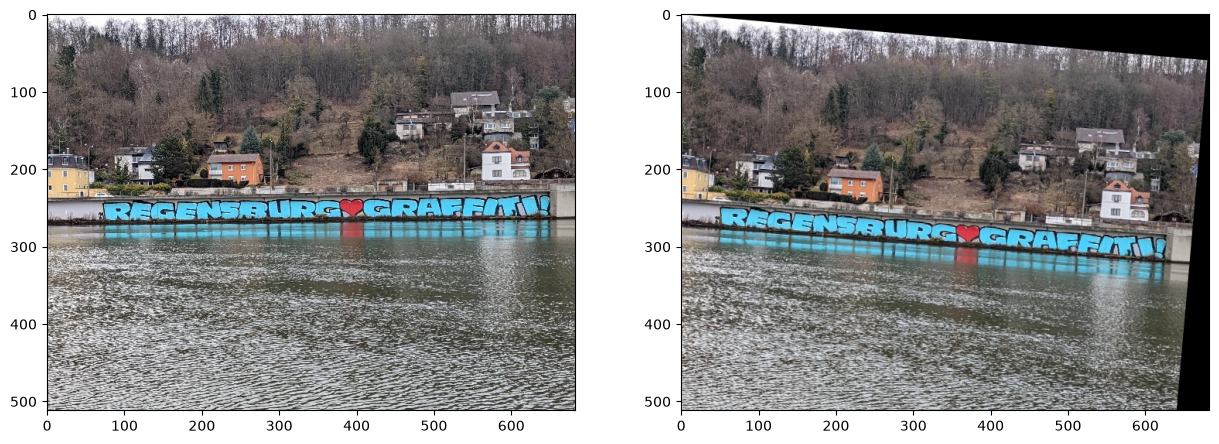

In [14]:
theta = np.deg2rad(5)
R = np.array([[np.cos(theta), -np.sin(theta), 0], [np.sin(theta), np.cos(theta), 0]])

out = cv2.warpAffine(img, R, (cols, rows))

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(out)

To account for the rotation not being center, we can build the rotation matrix with a built-in OpenCV function.

[[  0.70710678   0.70710678 -81.14274837]
 [ -0.70710678   0.70710678 316.1040764 ]] 512 683 256 341


(<Axes: >, <matplotlib.image.AxesImage at 0x7930226e27e0>)

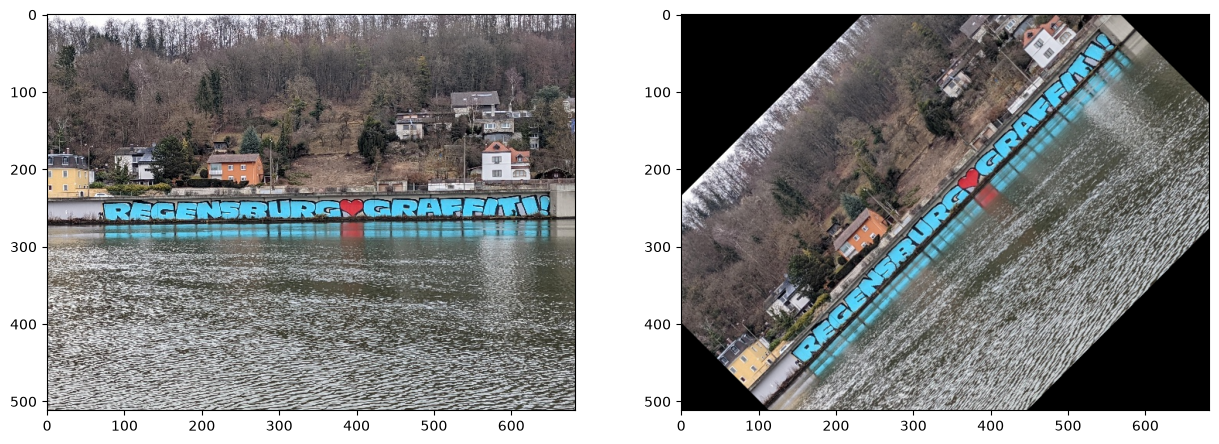

In [15]:
center = (cols//2, rows//2)
rotate_matrix = cv2.getRotationMatrix2D(center=center, angle=45, scale=1)

print(rotate_matrix, rows, cols, rows//2, cols//2)

out = cv2.warpAffine(img, rotate_matrix, (cols, rows))

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(out)

### Shear

Shear is the third basic component of an affine transform (together with scaling and rotation) — it skews the image along one axis while leaving the other axis untouched. Like scaling and rotation, it's a linear map, so it still preserves parallelism (parallel lines stay parallel) even though angles and lengths are no longer preserved.

(<Axes: >, <matplotlib.image.AxesImage at 0x793020bfa7e0>)

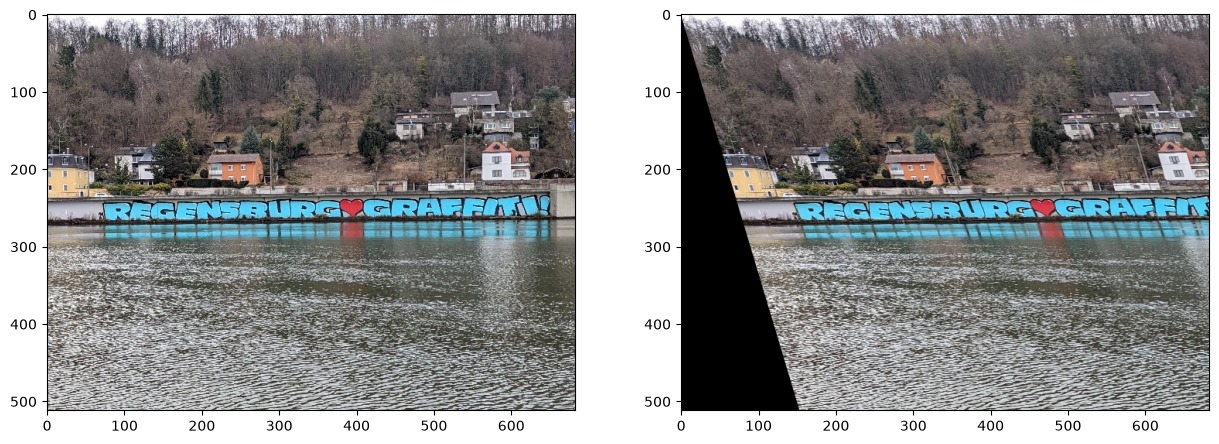

In [16]:
shear = 0.3
Sh = np.array([[1, shear, 0], [0, 1, 0]])

out = cv2.warpAffine(img, Sh, (cols, rows))

plt.subplot(121), plt.imshow(img)
plt.subplot(122), plt.imshow(out)

### Concatenation

Because every affine transform is just a matrix in homogeneous coordinates, we can **compose** several of them into a single matrix by multiplying the matrices together — instead of warping the image once per transform (which would resample it multiple times and blur it a bit more each time). Let's concatenate the zoom and the rotation from above into one matrix and check that a single `warpAffine` call with the combined matrix gives (up to interpolation differences) the same result as applying the two transforms one after another.

(<Axes: title={'center': 'Concatenated matrix (1 warp)'}>,
 Text(0.5, 1.0, 'Concatenated matrix (1 warp)'))

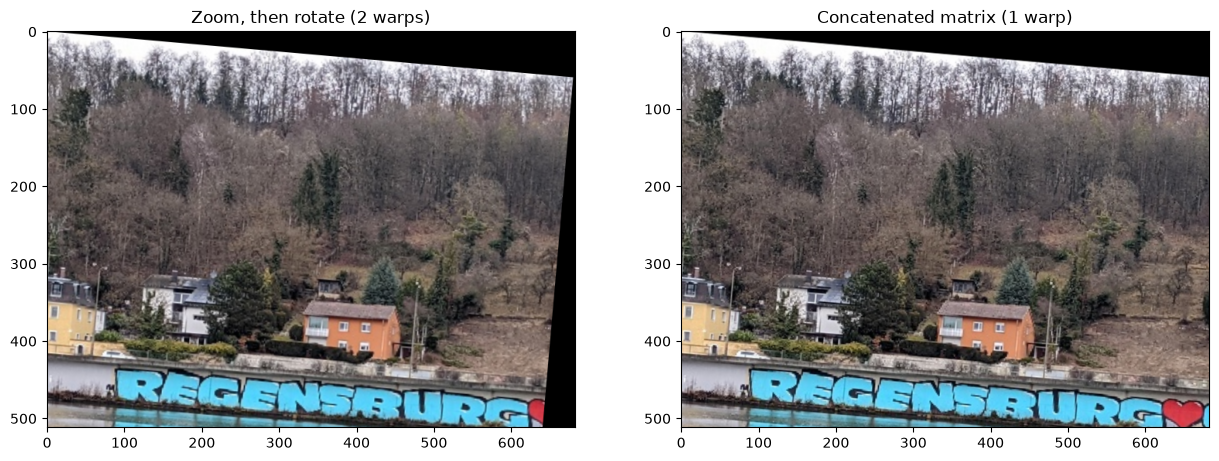

In [17]:
# Homogeneous (3x3) versions of the zoom and rotation matrices
Z3 = np.vstack([Z, [0, 0, 1]])
R3 = np.vstack([R, [0, 0, 1]])

# Concatenate: zoom first, then rotate
combined = (R3 @ Z3)[:2, :]

# Apply the two transforms one after another (double resampling)...
out_sequential = cv2.warpAffine(cv2.warpAffine(img, Z, (cols, rows)), R, (cols, rows))

# ...versus the single concatenated transform (single resampling)
out_combined = cv2.warpAffine(img, combined, (cols, rows))

plt.subplot(121), plt.imshow(out_sequential), plt.title('Zoom, then rotate (2 warps)')
plt.subplot(122), plt.imshow(out_combined), plt.title('Concatenated matrix (1 warp)')

### From Affine to Homography

Affine transforms are just one point on a broader spectrum of 2D correspondence maps, each with its own degrees of freedom (DOF) — the number of free parameters in the transform matrix:

| Transform | DOF | Preserves |
|---|---|---|
| Translation | 2 | orientation, shape, size |
| Euclidean / rigid (translation + rotation) | 3 | shape, size |
| Similarity (+ uniform scaling) | 4 | shape (angles) |
| Affine (+ shear / non-uniform scaling) | 6 | parallelism |
| Homography / projective | 8 | straight lines |

A **homography** is the next step up: a full perspective transform that no longer preserves parallelism (e.g. parallel railway tracks converge towards a vanishing point), only straight lines. It has 9 matrix entries but only 8 DOF, since the matrix is defined up to scale — after applying it, the result also needs to be normalized back to Cartesian coordinates by dividing through by the third (homogeneous) coordinate. We'll use homographies to stitch images together in the next notebook, `ImageStitching.ipynb`.